# ML Assignment 1 - Car Price Analysis



## Overview

Two tasks on the same cleaned dataset:

1. **Regression** (Linear Regression): predict the selling price.
2. **Classification** (KNN): bucket cars into Cheap, Moderate, Expensive.

Preprocessing is shared; the targets diverge in Task 3.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Upload the CSV file to Colab
from google.colab import files
uploaded = files.upload()  # Click the button and select car_price.csv

Saving car_price.csv to car_price.csv


In [ ]:
df = pd.read_csv('car_price.csv')
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 72435 rows, 10 columns


---
## Task 1: EDA

Before touching a model we need a read on the data: shape, types, missing values, distributions, and what correlates with price.

### 1.1 How many rows and columns does the dataset have?

In [ ]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn names: {df.columns.tolist()}')

Rows: 72435
Columns: 10

Column names: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']


In [ ]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


### 1.2 Which features are numerical? Which are categorical?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Numerical features (6): ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical features (4): ['model', 'transmission', 'fuelType', 'Make']


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


### 1.3 Are there any missing values? How many, and in which columns?

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
print(f'Rows with at least one missing value: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.1f}%)')

              Missing Count  Percentage (%)
model                  3621             5.0
year                   3622             5.0
price                  3621             5.0
transmission           3623             5.0
mileage                3622             5.0
fuelType               3622             5.0
tax                    3621             5.0
mpg                    3621             5.0
engineSize             3622             5.0
Make                   3621             5.0

Total missing cells: 36216
Rows with at least one missing value: 29110 (40.2%)


Every column has about 5% missing values (~3,621 each), and roughly 40% of rows contain at least one NaN. The missingness is spread evenly, which looks injected on purpose. Dropping those rows would throw away ~40% of the data, so we impute instead.

### 1.4 What does the distribution of car prices look like?

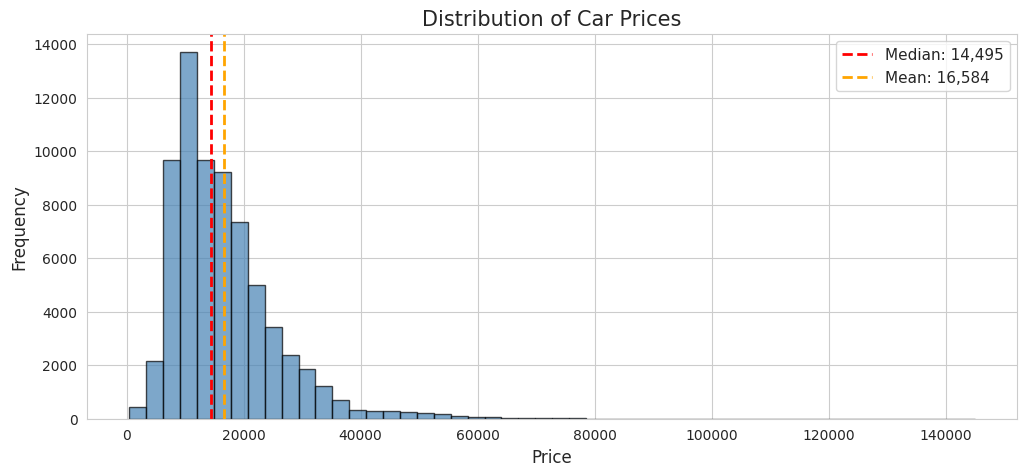

Skewness: 2.18 (positive = right-skewed)
Kurtosis: 10.27
Mean (16,584) > Median (14,495) confirms the right skew.


In [ ]:
plt.figure(figsize=(12, 5))
plt.hist(df['price'].dropna(), bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(df['price'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():,.0f}')
plt.axvline(df['price'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {df["price"].mean():,.0f}')
plt.title('Distribution of Car Prices', fontsize=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.show()

print(f'Skewness: {df["price"].skew():.2f} (positive = right-skewed)')
print(f'Kurtosis: {df["price"].kurtosis():.2f}')
print(f'Mean ({df["price"].mean():,.0f}) > Median ({df["price"].median():,.0f}) confirms the right skew.')

Price is right-skewed (skewness ~ 2.18). Most cars sit between 5,000 and 25,000 but a long tail runs up to 145,000 (e.g. Audi R8). That tail drags the mean above the median.

### 1.5 Which features seem most related to price?

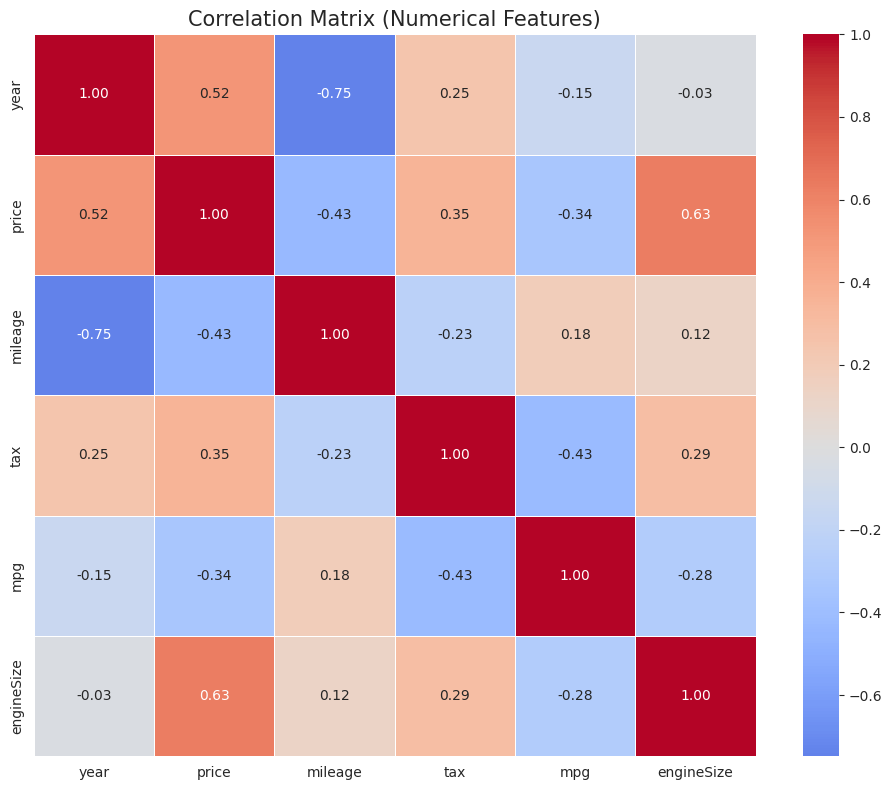


Correlations with price (sorted by strength):
engineSize    0.629839
year          0.519383
mileage      -0.427524
tax           0.353204
mpg          -0.335615
Name: price, dtype: float64


In [ ]:
# Correlation heatmap (numerical features only)
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix (Numerical Features)', fontsize=15)
plt.tight_layout()
plt.show()

print('\nCorrelations with price (sorted by strength):')
price_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)
print(corr_matrix['price'].drop('price').reindex(price_corr.index))

Observations:

- `engineSize` (+0.63) is the strongest linear predictor of price.
- `year` (+0.52): newer cars cost more.
- `mileage` (-0.43): more miles, lower price.
- `tax` (+0.35) and `mpg` (-0.34) are moderate.

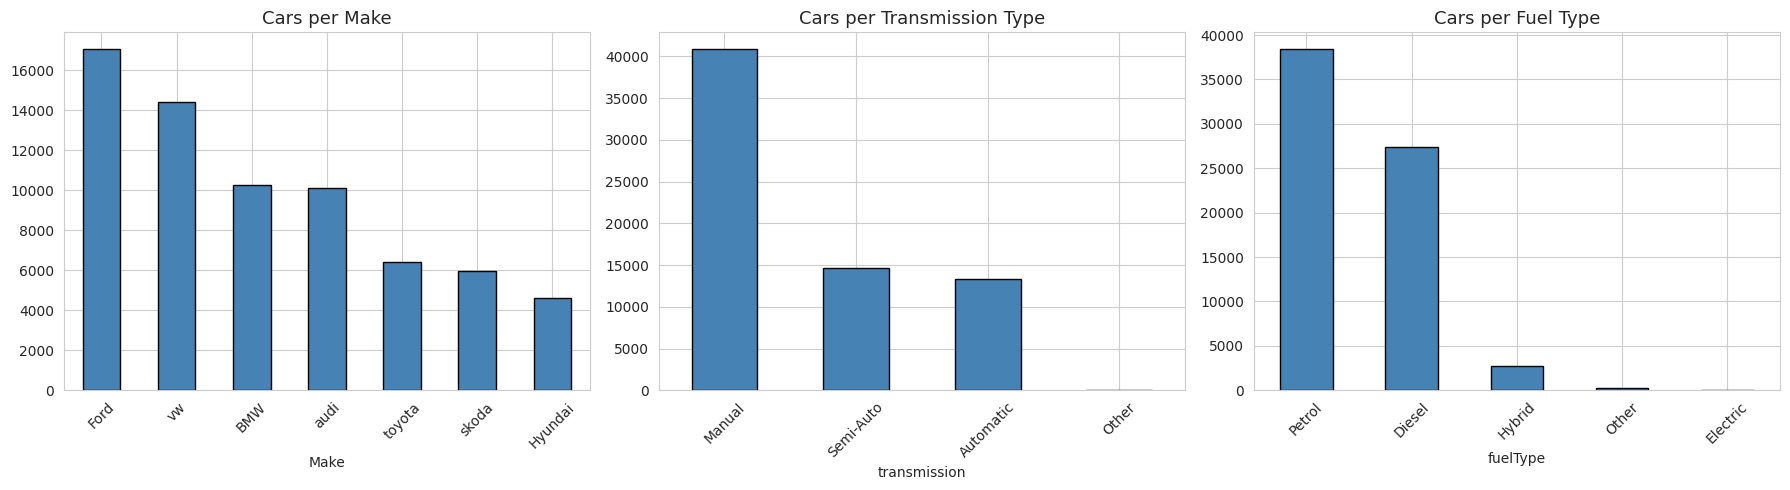

In [ ]:
# Categorical feature exploration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Make'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Cars per Make', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

df['transmission'].value_counts().plot.bar(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Cars per Transmission Type', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

df['fuelType'].value_counts().plot.bar(ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Cars per Fuel Type', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Task 2: Data Preprocessing

We apply the same preprocessing steps for both models. This includes cleaning, handling missing values, encoding, outlier treatment, and scaling.

### 2.1 Data Cleaning

In [ ]:
# 1. Strip leading whitespace from the 'model' column
df['model'] = df['model'].str.strip()

# 2. Standardize 'Make' casing (title case)
df['Make'] = df['Make'].str.title()

# 3. Drop exact duplicate rows
duplicates_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates_count}')
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

# 4. Replace engineSize == 0 with NaN (these are data errors, not real zeros)
zero_engine = (df['engineSize'] == 0).sum()
print(f'engineSize == 0 found: {zero_engine} (replacing with NaN)')
df['engineSize'] = df['engineSize'].replace(0, np.nan)

Duplicate rows found: 366
Shape after removing duplicates: (72069, 10)
engineSize == 0 found: 210 (replacing with NaN)


### 2.2 Handle Missing Values

We impute rather than drop, because dropping loses ~40% of the rows.

- Numerical columns: fill with the **median**. Price and mileage are right-skewed, so the mean gets pulled up by luxury outliers. The median is more robust.
- Categorical columns: fill with the **mode** (most frequent value).

`SimpleImputer` does both.

In [ ]:
# Numerical columns: impute with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='median')
df[num_cols] = numeric_imputer.fit_transform(df[num_cols])

# Categorical columns: impute with mode (most frequent)
cat_cols = df.select_dtypes(include='object').columns.tolist()
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = categorical_imputer.fit_transform(df[cat_cols])

# Verify no missing values remain
print('Remaining missing values:', df.isnull().sum().sum())

Remaining missing values: 0


### 2.3 Encode Categorical Columns

One-hot encode `transmission`, `fuelType`, and `Make`. These are nominal; label encoding would invent an order (Manual < Automatic?) that distorts a linear model.

We drop `model` entirely. It has 145 unique values, so one-hot would blow up the feature space (bad for KNN distance, easy overfit on linear regression). `Make` already captures most of the brand-level signal.

In [ ]:
# Drop 'model': 145 unique values would blow up the feature space after one-hot
df.drop(columns=['model'], inplace=True)
print(f'Remaining columns: {df.columns.tolist()}')

Remaining columns: ['year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']


In [ ]:
# One-Hot Encode: transmission, fuelType, Make
cols_to_encode = ['transmission', 'fuelType', 'Make']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[cols_to_encode])
encoded_cols = encoder.get_feature_names_out(cols_to_encode)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

# Merge encoded columns back and drop originals
df = pd.concat([df.drop(columns=cols_to_encode), encoded_df], axis=1)

print(f'Shape after encoding: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape after encoding: (72069, 19)
Columns: ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'Make_Bmw', 'Make_Ford', 'Make_Hyundai', 'Make_Skoda', 'Make_Toyota', 'Make_Vw']


### 2.4 Outliers

Standard IQR rule: anything outside [Q1 - 1.5·IQR, Q3 + 1.5·IQR] is flagged. We **cap** these values at the boundary instead of deleting the rows. A 145,000 Audi R8 is a real car, not a typo; capping just stops its weight from dominating the model.

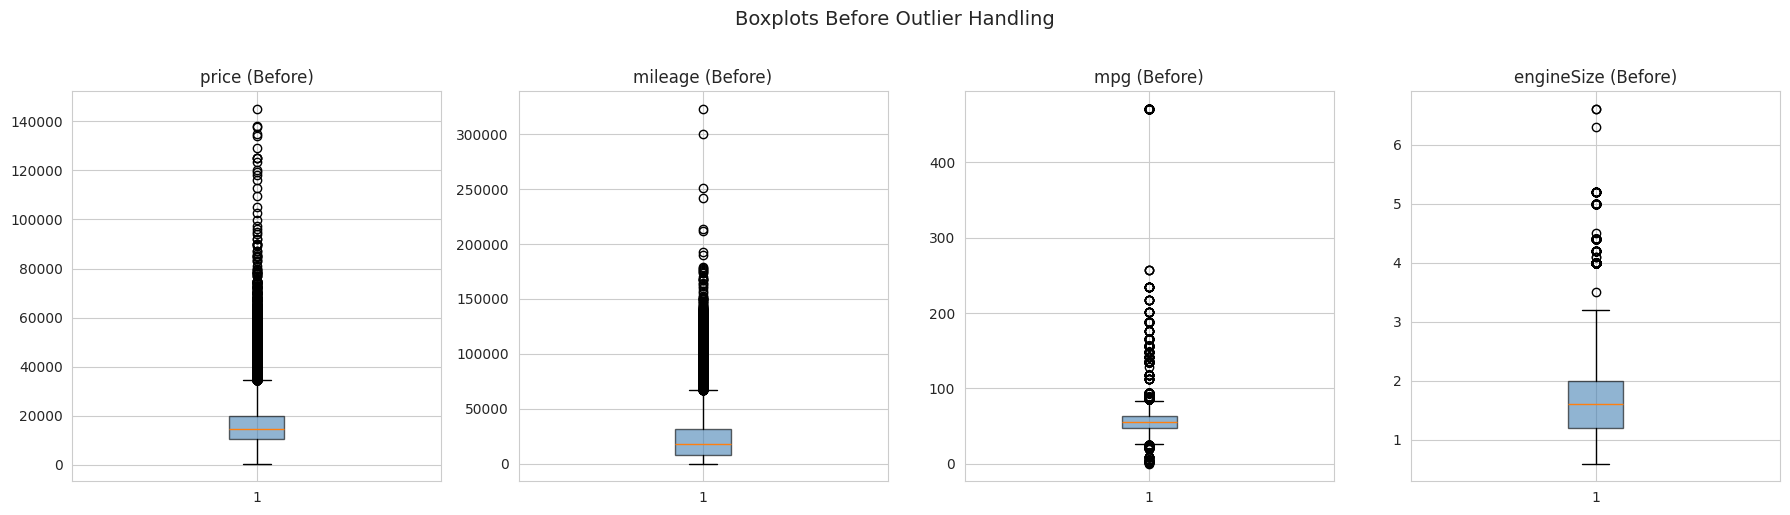

In [ ]:
# Boxplots BEFORE outlier handling
outlier_cols = ['price', 'mileage', 'mpg', 'engineSize']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col} (Before)', fontsize=12)
plt.suptitle('Boxplots Before Outlier Handling', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Apply IQR capping
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {outlier_count} outliers capped to [{lower:.1f}, {upper:.1f}]')
    df[col] = df[col].clip(lower=lower, upper=upper)

price: 2954 outliers capped to [-3985.0, 34375.0]
mileage: 3186 outliers capped to [-27872.0, 67256.0]
mpg: 1057 outliers capped to [25.6, 85.1]
engineSize: 327 outliers capped to [-0.0, 3.2]


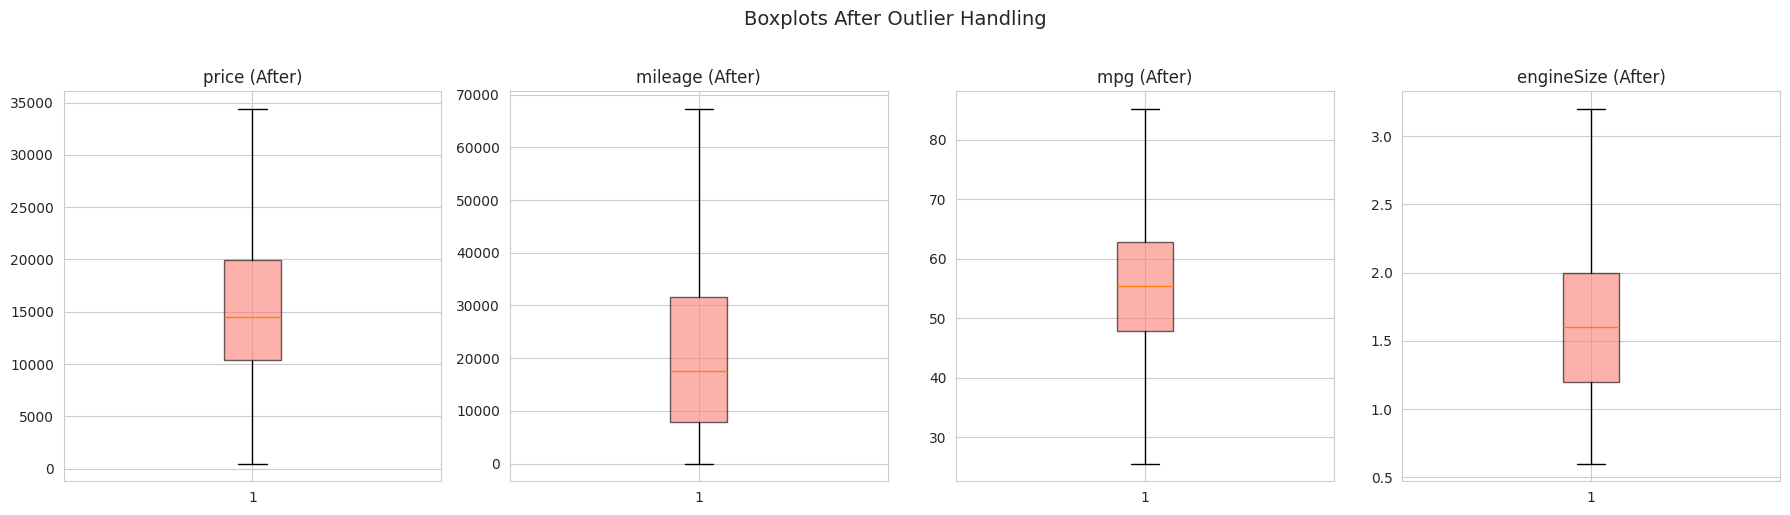

In [ ]:
# Boxplots AFTER outlier handling
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='salmon', alpha=0.6))
    axes[i].set_title(f'{col} (After)', fontsize=12)
plt.suptitle('Boxplots After Outlier Handling', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Task 3: Create Two Target Variables

### A. Regression Target (Linear Regression)

Use `price` directly. The model predicts the exact selling price.

In [ ]:
print(f'Regression target: price (continuous)')
print(f'Range: {df["price"].min():,.0f} to {df["price"].max():,.0f}')
print(f'Mean: {df["price"].mean():,.0f}, Median: {df["price"].median():,.0f}')

Regression target: price (continuous)
Range: 495 to 34,375
Mean: 16,017, Median: 14,495


### B. Classification Target (KNN)

Bin prices by the 33rd and 66th percentiles:

- `Cheap`: price ≤ P33
- `Moderate`: P33 < price ≤ P66
- `Expensive`: price > P66

Percentile cuts give three roughly equal classes (~1/3 each). If one class held 90% of the rows, a dummy classifier that always guesses that class would already hit 90% accuracy, so balance matters.

In [ ]:
# Calculate thresholds
p33 = df['price'].quantile(0.33)
p66 = df['price'].quantile(0.66)
print(f'33rd percentile: {p33:,.0f}')
print(f'66th percentile: {p66:,.0f}')

# Create categories
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, p33, p66, float('inf')],
    labels=['Cheap', 'Moderate', 'Expensive']
)

print(f'\nCategory distribution:')
print(df['price_category'].value_counts().sort_index())

33rd percentile: 11,690
66th percentile: 17,499

Category distribution:
price_category
Cheap        23783
Moderate     23847
Expensive    24439
Name: count, dtype: int64


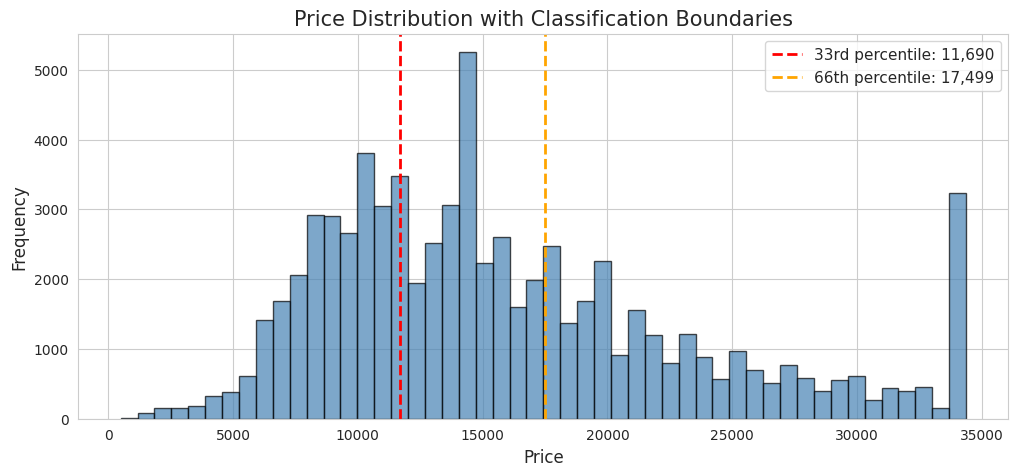

In [ ]:
# Visualize the thresholds on the price histogram
plt.figure(figsize=(12, 5))
plt.hist(df['price'], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(p33, color='red', linestyle='--', linewidth=2, label=f'33rd percentile: {p33:,.0f}')
plt.axvline(p66, color='orange', linestyle='--', linewidth=2, label=f'66th percentile: {p66:,.0f}')
plt.title('Price Distribution with Classification Boundaries', fontsize=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.show()

---
## Task 4: Linear Regression

Predict the exact car price with Linear Regression.

In [ ]:
# Prepare features and target for regression
X = df.drop(columns=['price', 'price_category'])
y_reg = df['price']

# 80/20 Train-Test Split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 57655 samples
Test set: 14414 samples


In [ ]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)

# Predict on test set
y_pred_reg = lr_model.predict(X_test)

In [ ]:
# Evaluate the regression model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print('=== Linear Regression Evaluation ===')
print(f'MAE  (Mean Absolute Error):  {mae:,.2f}')
print(f'MSE  (Mean Squared Error):   {mse:,.2f}')
print(f'RMSE (Root Mean Squared Error): {rmse:,.2f}')
print(f'R²   (R-squared):            {r2:.4f}')

=== Linear Regression Evaluation ===
MAE  (Mean Absolute Error):  2,499.41
MSE  (Mean Squared Error):   11,617,839.36
RMSE (Root Mean Squared Error): 3,408.50
R²   (R-squared):            0.7918


In [ ]:
# Print the model equation
feature_names = X_train.columns.tolist()
print('=== Model Equation ===')
equation_parts = [f'{lr_model.intercept_:.2f}']
for name, coef in zip(feature_names, lr_model.coef_):
    equation_parts.append(f'({coef:.4f} × {name})')
print(f'Price = {" + ".join(equation_parts)}')

# Show top 5 most influential features
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr_model.coef_})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print('\nTop 5 most influential features:')
print(coef_df[['Feature', 'Coefficient']].head().to_string(index=False))

=== Model Equation ===
Price = -2452551.85 + (1228.3629 × year) + (-0.0880 × mileage) + (-2.5985 × tax) + (-177.5514 × mpg) + (4633.1902 × engineSize) + (-1792.4490 × transmission_Manual) + (-1713.5379 × transmission_Other) + (340.9980 × transmission_Semi-Auto) + (-826.3334 × fuelType_Electric) + (4650.6895 × fuelType_Hybrid) + (1796.6861 × fuelType_Other) + (-1593.1243 × fuelType_Petrol) + (-1345.1051 × Make_Bmw) + (-3516.8634 × Make_Ford) + (-5540.8010 × Make_Hyundai) + (-3945.1872 × Make_Skoda) + (-5206.4346 × Make_Toyota) + (-2688.7208 × Make_Vw)

Top 5 most influential features:
        Feature  Coefficient
   Make_Hyundai -5540.801048
    Make_Toyota -5206.434606
fuelType_Hybrid  4650.689547
     engineSize  4633.190250
     Make_Skoda -3945.187156


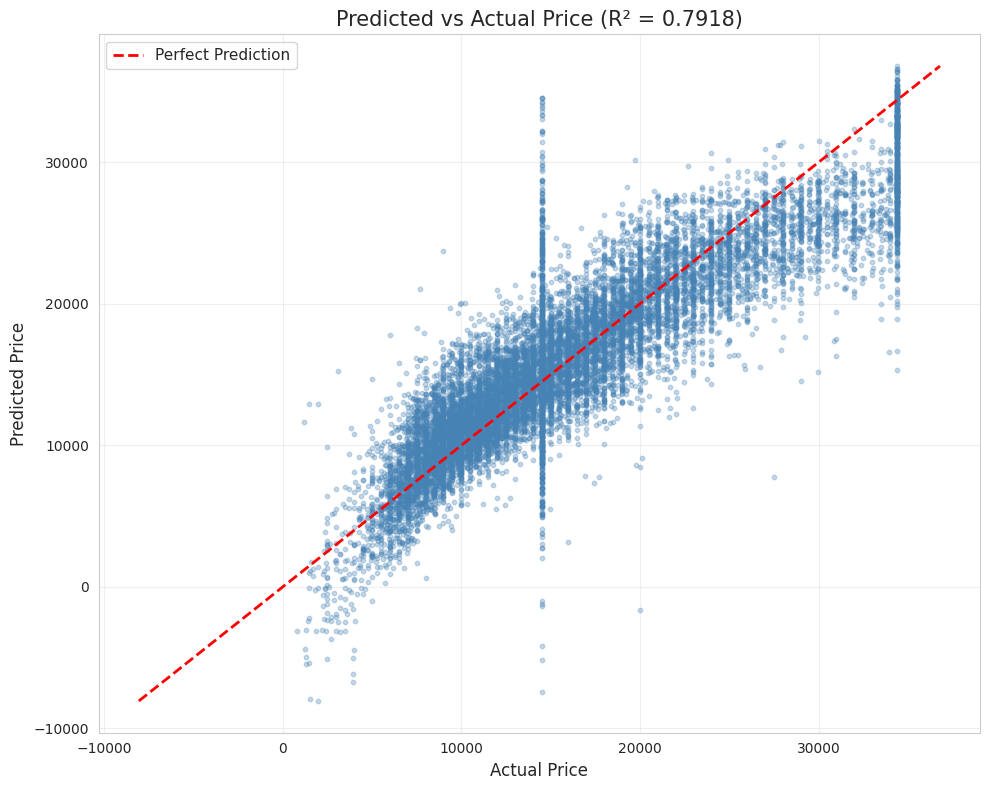

In [ ]:
# Predicted vs Actual scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color='steelblue', s=10)
# Perfect prediction line
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Predicted vs Actual Price (R² = {r2:.4f})', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 5: KNN Classification

Predict the price bucket (Cheap / Moderate / Expensive) with KNN.

In [ ]:
# Prepare features and target for classification
y_cls = df['price_category']

# 80/20 Train-Test Split (same X as regression)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

print(f'Training set: {X_train_cls.shape[0]} samples')
print(f'Test set: {X_test_cls.shape[0]} samples')

Training set: 57655 samples
Test set: 14414 samples


In [ ]:
# KNN uses distance, so standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cls)
X_test_scaled = scaler.transform(X_test_cls)

print('Scaled. fit_transform on train, transform on test (no leakage).')

Scaled. fit_transform on train, transform on test (no leakage).


In [ ]:
# GridSearchCV with KFold to find the best K and distance metric
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_cls)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7}
Best CV Accuracy: 0.8194


In [ ]:
# Evaluate the best model on the test set
best_knn = grid_search.best_estimator_
y_pred_cls = best_knn.predict(X_test_scaled)

print('=== KNN Classification Evaluation ===')
print(f'Accuracy:  {accuracy_score(y_test_cls, y_pred_cls):.4f}')
print(f'Precision: {precision_score(y_test_cls, y_pred_cls, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test_cls, y_pred_cls, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test_cls, y_pred_cls, average="weighted"):.4f}')
print(f'\n--- Classification Report ---')
print(classification_report(y_test_cls, y_pred_cls))

=== KNN Classification Evaluation ===
Accuracy:  0.8270
Precision: 0.8250
Recall:    0.8270
F1-Score:  0.8256

--- Classification Report ---
              precision    recall  f1-score   support

       Cheap       0.85      0.88      0.86      4668
   Expensive       0.86      0.89      0.88      4980
    Moderate       0.76      0.71      0.74      4766

    accuracy                           0.83     14414
   macro avg       0.82      0.83      0.83     14414
weighted avg       0.83      0.83      0.83     14414



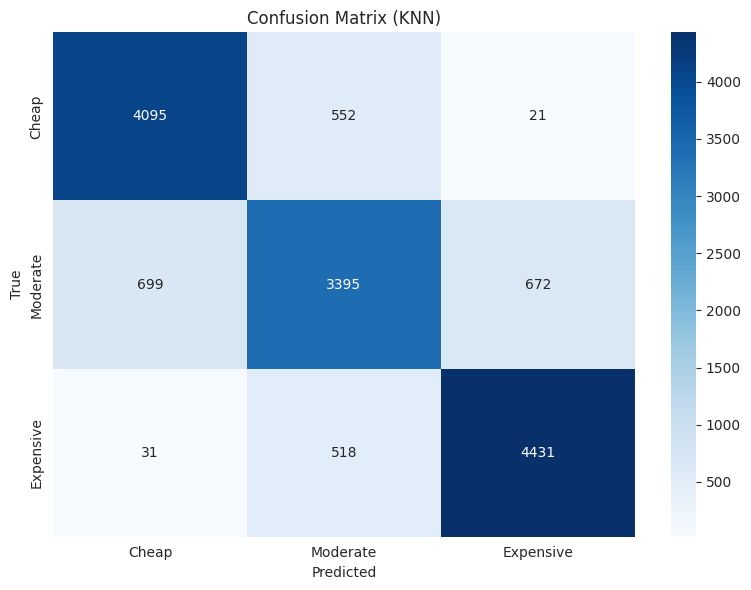

In [ ]:
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=['Cheap', 'Moderate', 'Expensive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

---
## Task 6: Analysis and Discussion

### 6.1 Model Comparison

The two models don't measure the same thing, so comparing raw numbers directly is a bit unfair.

Linear Regression reaches R² ≈ 0.79 and RMSE ≈ 3,408. KNN reaches ~83% weighted accuracy and F1 ≈ 0.83. "Better" for the regression means the predicted price is close to the actual price. "Better" for the classifier means the right bucket. A dealer pricing inventory needs regression; a buyer browsing listings only needs the bucket.

Classification looks easier on this dataset because it collapses an infinite-valued target into 3 options. Regression has to distinguish 14,495 from 14,800 (any difference is an error). The classifier just has to agree both are "Moderate". The trade-off shows up at the boundaries: 11,449 (Cheap) and 11,451 (Moderate) are basically the same car, labelled differently.

Converting price to categories definitely loses information. Inside the "Cheap" bucket, a 1,000 car and a 10,000 car are treated as equal, and the boundaries themselves are arbitrary cuts, not real changes in the underlying data. Once we go to categories we can't recover the exact price, so any downstream use that needs precise pricing has to fall back on the regression model.

### 6.2 Sensitivity Analysis

#### Experiment 1: Remove the most correlated feature

`engineSize` has the highest correlation with price (+0.63). Dropping it and retraining both models tells us how much each model leans on that single feature.

In [ ]:
# Remove engineSize and retrain both models
X_no_engine = X.drop(columns=['engineSize'])

# --- Regression without engineSize ---
X_tr_ne, X_te_ne, y_tr_ne, y_te_ne = train_test_split(
    X_no_engine, y_reg, test_size=0.2, random_state=42
)
lr_no_engine = LinearRegression()
lr_no_engine.fit(X_tr_ne, y_tr_ne)
y_pred_ne = lr_no_engine.predict(X_te_ne)

r2_no_engine = r2_score(y_te_ne, y_pred_ne)
rmse_no_engine = np.sqrt(mean_squared_error(y_te_ne, y_pred_ne))

print('=== Regression: engineSize removed ===')
print(f'R² with engineSize:    {r2:.4f}')
print(f'R² without engineSize: {r2_no_engine:.4f}')
print(f'R² drop:               {r2 - r2_no_engine:.4f}')
print(f'\nRMSE with engineSize:    {rmse:,.2f}')
print(f'RMSE without engineSize: {rmse_no_engine:,.2f}')

=== Regression: engineSize removed ===
R² with engineSize:    0.7918
R² without engineSize: 0.7550
R² drop:               0.0368

RMSE with engineSize:    3,408.50
RMSE without engineSize: 3,697.39


In [ ]:
# --- Classification without engineSize ---
X_tr_ne_c, X_te_ne_c, y_tr_ne_c, y_te_ne_c = train_test_split(
    X_no_engine, y_cls, test_size=0.2, random_state=42
)

scaler_ne = StandardScaler()
X_tr_ne_scaled = scaler_ne.fit_transform(X_tr_ne_c)
X_te_ne_scaled = scaler_ne.transform(X_te_ne_c)

knn_no_engine = KNeighborsClassifier(**grid_search.best_params_)
knn_no_engine.fit(X_tr_ne_scaled, y_tr_ne_c)
y_pred_ne_c = knn_no_engine.predict(X_te_ne_scaled)

acc_original = accuracy_score(y_test_cls, y_pred_cls)
acc_no_engine = accuracy_score(y_te_ne_c, y_pred_ne_c)

print('=== Classification: engineSize removed ===')
print(f'Accuracy with engineSize:    {acc_original:.4f}')
print(f'Accuracy without engineSize: {acc_no_engine:.4f}')
print(f'Accuracy drop:               {acc_original - acc_no_engine:.4f}')

=== Classification: engineSize removed ===
Accuracy with engineSize:    0.8270
Accuracy without engineSize: 0.8066
Accuracy drop:               0.0205


Dropping `engineSize` costs R² about 0.04 and KNN accuracy about 0.02. Both models degrade but neither collapses, because `year` and `mileage` still carry a lot of the signal on their own.

#### Experiment 2: KNN without scaling

KNN uses raw Euclidean or Manhattan distance, so features with large numeric ranges dominate. Running the best KNN on unscaled features shows how much scaling actually buys us here.

In [ ]:
# KNN on raw, unscaled features
knn_unscaled = KNeighborsClassifier(**grid_search.best_params_)
knn_unscaled.fit(X_train_cls, y_train_cls)
y_pred_unscaled = knn_unscaled.predict(X_test_cls)

acc_scaled = accuracy_score(y_test_cls, y_pred_cls)
acc_unscaled = accuracy_score(y_test_cls, y_pred_unscaled)

print(f'Accuracy (scaled):   {acc_scaled:.4f}')
print(f'Accuracy (unscaled): {acc_unscaled:.4f}')
print(f'Drop:                {acc_scaled - acc_unscaled:.4f}')

# Feature ranges in the training set (after IQR capping)
mileage_rng = (X_train_cls['mileage'].min(), X_train_cls['mileage'].max())
engine_rng = (X_train_cls['engineSize'].min(), X_train_cls['engineSize'].max())
print(f'\nmileage range:    {mileage_rng[0]:,.0f} to {mileage_rng[1]:,.0f}')
print(f'engineSize range: {engine_rng[0]:.1f} to {engine_rng[1]:.1f}')

Accuracy (scaled):   0.8270
Accuracy (unscaled): 0.5559
Drop:                0.2711

mileage range:    1 to 67,256
engineSize range: 0.6 to 3.2


#### Experiment 3: Different thresholds for price categories

Swapping the cut-offs from 33/66 to 25/75 makes Moderate bigger and the two ends smaller. If KNN accuracy shifts a lot, the category labels are more about how we slice the data than about the cars themselves.

In [ ]:
p25 = df['price'].quantile(0.25)
p75 = df['price'].quantile(0.75)

print(f'Original cuts: P33={p33:,.0f}, P66={p66:,.0f}')
print(f'New cuts:      P25={p25:,.0f}, P75={p75:,.0f}')

y_cls_new = pd.cut(
    df['price'], bins=[0, p25, p75, float('inf')],
    labels=['Cheap', 'Moderate', 'Expensive']
)
print('\nNew class counts:')
print(y_cls_new.value_counts().sort_index())

X_tr_new, X_te_new, y_tr_new, y_te_new = train_test_split(
    X, y_cls_new, test_size=0.2, random_state=42
)
scaler_new = StandardScaler()
X_tr_new_scaled = scaler_new.fit_transform(X_tr_new)
X_te_new_scaled = scaler_new.transform(X_te_new)

knn_new = KNeighborsClassifier(**grid_search.best_params_)
knn_new.fit(X_tr_new_scaled, y_tr_new)
acc_new = accuracy_score(y_te_new, knn_new.predict(X_te_new_scaled))

print(f'\nAccuracy (P33/P66): {acc_scaled:.4f}')
print(f'Accuracy (P25/P75): {acc_new:.4f}')

Original cuts: P33=11,690, P66=17,499
New cuts:      P25=10,400, P75=19,990

New class counts:
price
Cheap        18025
Moderate     36086
Expensive    17958
Name: count, dtype: int64

Accuracy (P33/P66): 0.8270
Accuracy (P25/P75): 0.8438


---
## Task 7: Required Visualizations

The mandatory plots (price histogram, correlation heatmap, predicted vs actual scatter, confusion matrix) are already included above. Below are 2 additional meaningful plots.

### Extra Plot 1: Price by Make

Boxplot of price per brand. Audi and BMW sit higher, Ford / Toyota / Hyundai lower. The ordering matches the sign and size of the `Make_*` coefficients in the regression model, which is a sanity check that the one-hot encoding actually captured brand-level price effects.

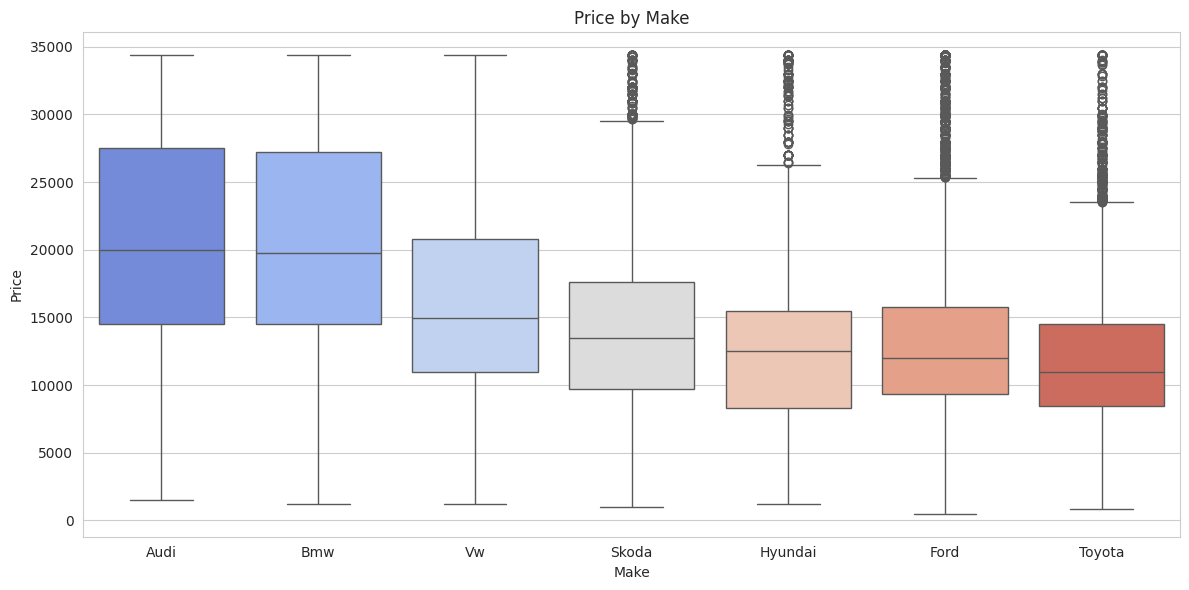

In [ ]:
# Rebuild Make from the one-hot columns so we can plot per brand
make_cols = [c for c in df.columns if c.startswith('Make_')]
make_names = [c.replace('Make_', '') for c in make_cols]
all_makes = ['Audi', 'Bmw', 'Ford', 'Hyundai', 'Skoda', 'Toyota', 'Vw']
ref_make = [m for m in all_makes if m not in make_names][0]  # dropped by drop='first'

def get_make(row):
    for col in make_cols:
        if row[col] == 1:
            return col.replace('Make_', '')
    return ref_make

df_plot = df[make_cols + ['price']].copy()
df_plot['Make'] = df_plot.apply(get_make, axis=1)

plt.figure(figsize=(12, 6))
order = df_plot.groupby('Make')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='Make', y='price', order=order, palette='coolwarm')
plt.title('Price by Make')
plt.xlabel('Make')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

### Extra Plot 2: KNN accuracy vs K

Cross-validated accuracy from GridSearchCV, one curve per metric. Small K is noisy (low bias, high variance); large K oversmooths (high bias). The curve shows the sweet spot and lets us compare Euclidean vs Manhattan at a glance.

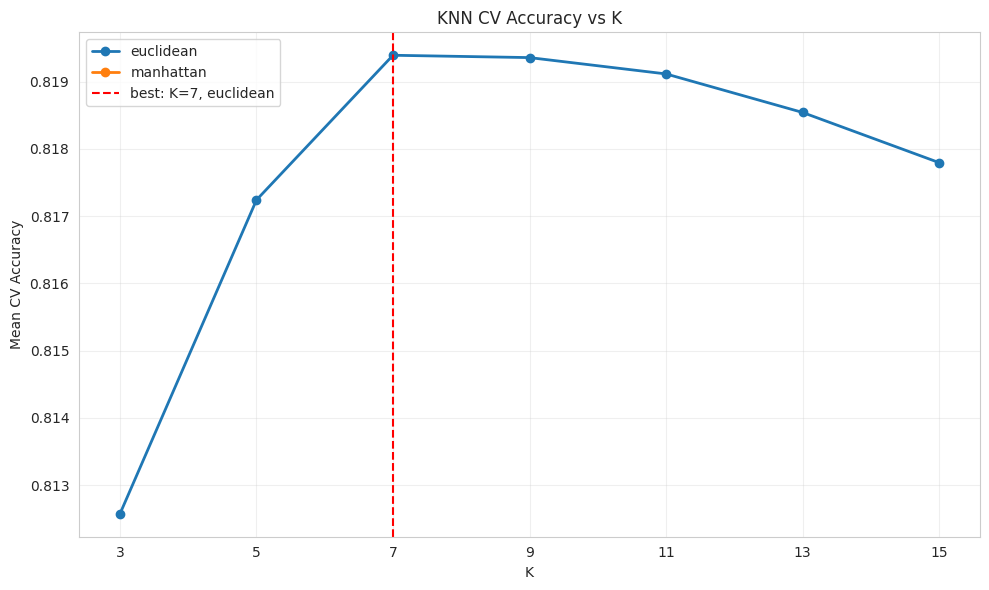

Best: K=7, metric=euclidean


In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 6))
for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'],
             label=f'{metric}', marker='o', linewidth=2)

best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--', linewidth=1.5,
            label=f'best: K={best_k}, {best_metric}')

plt.title('KNN CV Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Mean CV Accuracy')
plt.xticks([3, 5, 7, 9, 11, 13, 15])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best: K={best_k}, metric={best_metric}')